# Estimation & Hypothesis Testing

## Imports & Load Clean Data 

In [2]:
import pandas as pd                                       
import numpy as np 
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns  

df = pd.read_csv("../data/cleaned/saas_sales_clean.csv")                               
df.shape

(9994, 22)

## Act 1: The Protagonist — Estimating the AWS SaaS Customer
  Based on our sample of ~10,000 transactions, we estimate the characteristics of the
  overall AWS SaaS customer population using 95% confidence intervals.

In [4]:
# Calculate 95% confidence intervals for key metrics                                   
metrics = ["Sales", "Profit", "Profit Margin", "Discount"]
                                                                                         
for metric in metrics:
    data = df[metric].dropna()                                                         
    mean = data.mean()                                    
    ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=stats.sem(data))
    print(f"{metric}: Mean = {mean:.2f}, 95% CI = [{ci[0]:.2f}, {ci[1]:.2f}]")
                                                                                         

Sales: Mean = 229.86, 95% CI = [217.64, 242.08]
Profit: Mean = 28.66, 95% CI = [24.06, 33.25]
Profit Margin: Mean = 12.03, 95% CI = [11.12, 12.95]
Discount: Mean = 0.16, 95% CI = [0.15, 0.16]


```
Haarklein erklärt:
- stats.t.interval() → Konfidenzintervall mit der t-Verteilung (t-distribution)        
- 0.95 → 95% Konfidenzniveau — "Wenn wir 100 Samples ziehen, liegt der wahre Wert in 95
davon in diesem Intervall"                                                            
- len(data)-1 → Freiheitsgrade (degrees of freedom) = n - 1                            
- loc=mean → Zentrum = unser Sample-Mittelwert             
- stats.sem(data) → Standard Error of the Mean = std / √n — je größer n, desto kleiner 
der Fehler
```

### Confidence Interval Visualization

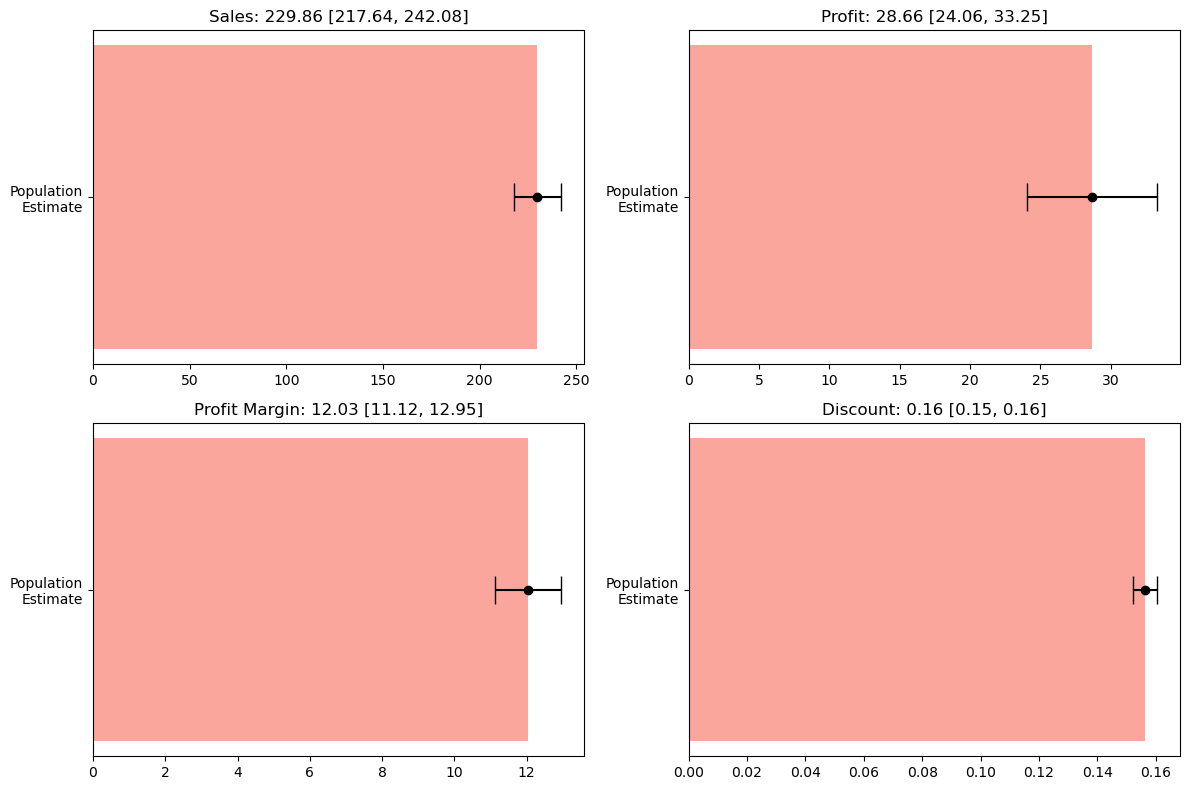

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))                                        
axes = axes.flatten()                          
                                                                                         
for i, metric in enumerate(metrics):                      
    data = df[metric].dropna()      
    mean = data.mean()        
    ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=stats.sem(data))
                                                                                         
    axes[i].barh(["Population\nEstimate"], [mean], color="salmon", alpha=0.7)
    axes[i].errorbar(mean, 0, xerr=[[mean - ci[0]], [ci[1] - mean]], fmt="o",          
color="black", capsize=10)                                                   
    axes[i].set_title(f"{metric}: {mean:.2f} [{ci[0]:.2f}, {ci[1]:.2f}]")              
                                                                           
plt.tight_layout()                                                                     
plt.savefig("../figures/estimation_ci.png")
plt.show() 

```
Wie du den Plot liest:
  - Balken = Mittelwert aus unserem Sample                                               
  - Schwarze Linie mit Kappen = 95% Confidence Interval
  - Je kürzer die Linie, desto präziser unsere Schätzung                                 
  - Bei n=10,000 werden die CIs sehr eng sein — unser Sample ist groß genug
```

**Was wir jetzt über den "typischen AWS SaaS Kunden" sagen können:**                       
   
  "Wir schätzen mit 95% Sicherheit, dass der durchschnittliche AWS SaaS Kunde pro      
  Transaktion zwischen $217 und $242 ausgibt, dabei einen Profit von $24–$33 generiert, 
  mit einer Marge von 11–13% und einem Rabatt von ca. 15–16%."                           
                                                                                         
  Was fällt auf:
  - Sales CI ist relativ breit ($217–$242, Spanne ~$25) — wegen der hohen Skewness und
  Outliers                                                                               
  - Discount CI ist extrem eng (0.15–0.16) — weil Discounts in festen Stufen vergeben
  werden, wenig Varianz                                                                  
  - Profit Margin CI (11–13%) — für SaaS eher niedrig, typisch wären 60-80%. Das zeigt   
  wie stark die Rabatte reinhauen                                                     
                                                                                         
                 
                                                                                         
  

### Estimation Summary                                    
                                                                                         
  | Metric | Population Estimate | 95% CI |                 
  |---|---|---|
  | Sales per Transaction | $229.86 | [$217.64, $242.08] |
  | Profit per Transaction | $28.66 | [$24.06, $33.25] |                                 
  | Profit Margin | 12.03% | [11.12%, 12.95%] |
  | Discount Rate | 16% | [15%, 16%] |  

                                                            

We estimate with 95% confidence that the average AWS SaaS transaction generates      
between $217 and $242 in sales, with a profit of $24–$33 and a margin of 11–13%. The
average discount rate is tightly estimated around 15–16%. 

## Act 2: The Hero Stories 

### BQ1: Do AWS SaaS customers in wealthier countries generate higher profit?          
  - H₀: GDP per capita has no predictive power for profit per transaction                
  - H₁: GDP per capita is a significant predictor of profit per transaction              
  - Test: Linear Regression

In [6]:
# Aggregate by country — average profit and GDP per capita                             
df_country = df.groupby("Country").agg(                   
    Avg_Profit=("Profit", "mean"),                                                     
    GDP_per_Capita=("GDP_per_Capita", "first"),                                        
    Transactions=("Profit", "count")                                                   
).dropna().reset_index()                                                               
                                                            
df_country.shape 

(47, 4)

```
Warum aggregieren? Jedes Land hat einen GDP-Wert, aber viele Transaktionen. Wenn wir
nicht aggregieren, würden Länder mit vielen Transaktionen (z.B. USA) das Ergebnis      
dominieren. Mit groupby("Country") bekommen wir einen Datenpunkt pro Land — fairer
Vergleich.
```

In [7]:
# Linear Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_country["GDP_per_Capita"], df_country["Avg_Profit"]     
)                                                                                      
                                                                                         
print(f"Slope: {slope:.6f}")                                                           
print(f"R-squared: {r_value**2:.4f}")                                                  
print(f"P-value: {p_value:.4f}")

Slope: 0.000121
R-squared: 0.0053
P-value: 0.6264


```
Haarklein erklärt:                                                                     
- stats.linregress() → berechnet die Regressionsgerade y = slope * x + intercept
- Slope (Steigung): Um wie viel Dollar steigt der Profit, wenn GDP per Capita um $1    
steigt                                                                             
- R-squared (Bestimmtheitsmaß): Wie viel % der Profit-Varianz wird durch GDP erklärt. 0
= gar nichts, 1 = alles                                                               
- P-value: Wahrscheinlichkeit, dieses Ergebnis zu sehen wenn H₀ wahr wäre. Unter 0.05 =
signifikant = H₀ ablehnen 
```

Ok, klares Ergebnis:                                                                   
                                                                                         
  - P-value = 0.63 → weit über 0.05 → H₀ NOT rejected                                    
  - R² = 0.005 → GDP erklärt nur 0.5% der Profit-Varianz — praktisch nichts              
  - Slope = 0.000121 → selbst wenn GDP um $10,000 steigt, steigt der Profit nur um $1.21 
                                                                                         
  Fazit: GDP per Capita hat keinen signifikanten Einfluss auf den Profit pro Transaktion.
                                                                                         
  Das ist übrigens kein schlechtes Ergebnis! In der Präsentation sagst du:               
                                                            
"We expected wealthier countries to generate more profit, but the data tells a different story — GDP per capita does not predict SaaS profitability. This suggests AWS SaaS pricing and profit are driven by internal factors (like discounts and segment) rather than external economic conditions." 

#### BQ1 Visualization

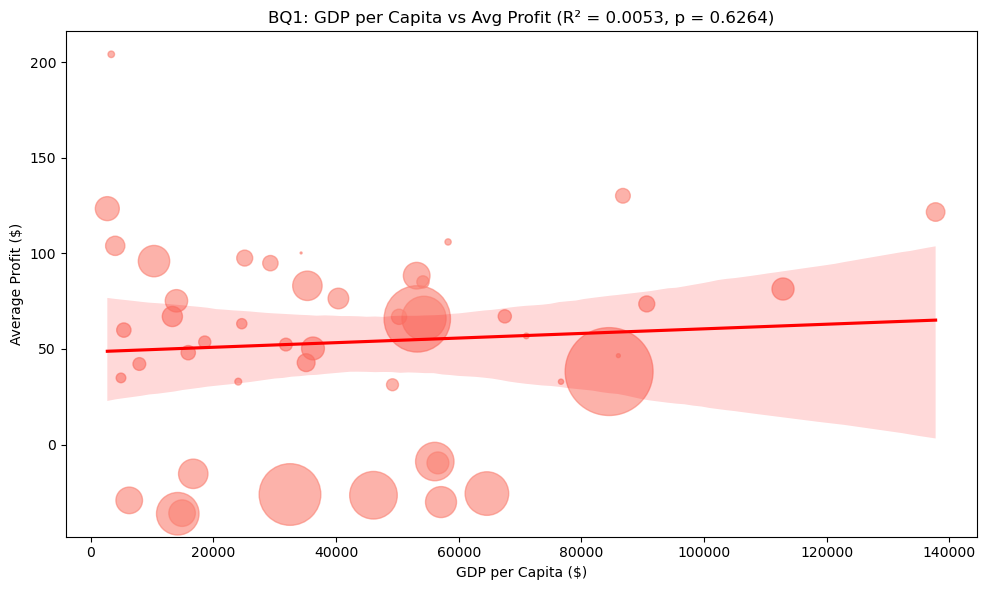

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))                                                
                                         
# Scatter plot with regression line                                                    
sns.regplot(data=df_country, x="GDP_per_Capita", y="Avg_Profit",
            scatter_kws={"s": df_country["Transactions"]*2, "alpha": 0.6},             
            line_kws={"color": "red"}, color="salmon", ax=ax)             
                                                                                         
ax.set_xlabel("GDP per Capita ($)")                                                    
ax.set_ylabel("Average Profit ($)")                                                    
ax.set_title(f"BQ1: GDP per Capita vs Avg Profit (R² = {r_value**2:.4f}, p = {p_value:.4f})")                                                             
                                                                                         
plt.tight_layout()
plt.savefig("../figures/bq1_gdp_profit.png")                                           
plt.show()     

```
Wie du den Plot liest:                                                                 
  - Jeder Punkt = ein Land
  - Größe des Punkts = Anzahl Transaktionen (größer = mehr Transaktionen)                
  - Rote Linie = Regressionsgerade — zeigt den Trend                     
  - Schattierter Bereich um die Linie = 95% Confidence Interval der Regression           
  - Steigt die Linie nach rechts oben → positive Beziehung (reichere Länder = mehr     Profit)                                                                                
  - Punkte weit von der Linie = Ausreißer, die nicht ins Muster passen 
  ```

#### BQ1 Result

  | Metric | Value | Interpretation |                                                    
  |---|---|---|
  | Slope | 0.000121 | +$1.21 profit per $10,000 GDP increase |                          
  | R² | 0.0053 | GDP explains only 0.5% of profit variance |                            
  | P-value | 0.6264 | Not significant (> 0.05) |
                                                                                         
  **Result: H₀ not rejected.** GDP per capita has no significant predictive power for    
  profit per transaction. SaaS profitability appears to be driven by internal factors    
  (discounts, segment) rather than a country's wealth.

### BQ2: Is AWS SaaS adoption higher in countries with better internet access?        
  - H₀: There is no relationship between internet penetration and number of transactions 
  - H₁: Countries with higher internet penetration have significantly more transactions  
  - Test: Pearson Correlation 

In [9]:
# Aggregate by country — transaction count and internet penetration                    
df_country2 = df.groupby("Country").agg(                                               
    Transactions=("Profit", "count"),                     
    Internet_Penetration=("Internet_Penetration", "first")                             
).dropna().reset_index()                                  
                                                                                         
# Pearson correlation                                     
r, p_value = stats.pearsonr(df_country2["Internet_Penetration"],                       
df_country2["Transactions"])                                    
                                                                                         
print(f"Pearson r: {r:.4f}")                              
print(f"P-value: {p_value:.4f}")

Pearson r: 0.0749
P-value: 0.6169


```
Haarklein erklärt:                                                                     
  - stats.pearsonr() → berechnet den Pearson-Korrelationskoeffizienten und den P-value
  - r (Korrelation): -1 bis +1. Positiv = je mehr Internet, desto mehr Transaktionen     
  - P-value: Unter 0.05 = signifikant
```

Wieder klar: H₀ NOT rejected. r = 0.07 ist praktisch keine Korrelation, P-value weit   
über 0.05.                                                                             
                                                                                         
Interessant — beide World Bank Hypothesen zeigen: Externe Wirtschaftsfaktoren spielen  
keine Rolle für AWS SaaS Performance. Das ist ein starkes Finding für die Präsentation!

#### BQ2 Visualization

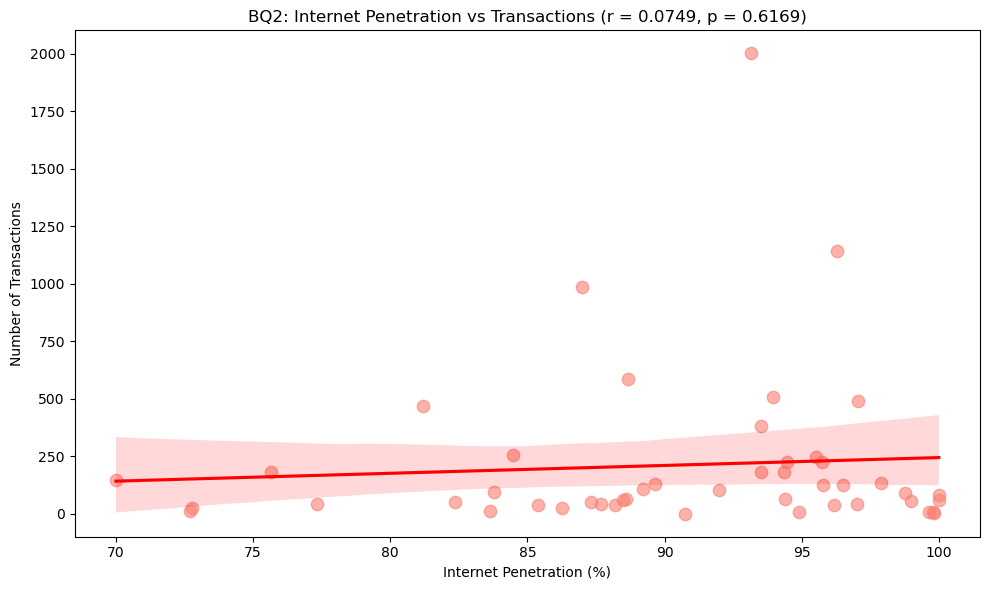

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))                   
                                         
sns.regplot(data=df_country2, x="Internet_Penetration", y="Transactions",
            scatter_kws={"s": 80, "alpha": 0.6},                                       
            line_kws={"color": "red"}, color="salmon", ax=ax)
                                                                                         
ax.set_xlabel("Internet Penetration (%)")                                              
ax.set_ylabel("Number of Transactions")  
ax.set_title(f"BQ2: Internet Penetration vs Transactions (r = {r:.4f}, p = {p_value:.4f})")                                          
                                                                                         
plt.tight_layout()
plt.savefig("../figures/bq2_internet_transactions.png")                                
plt.show() 

#### BQ2 Result                                                                        
                                                            
  | Metric | Value | Interpretation |
  |---|---|---|
  | Pearson r | 0.0749 | Almost no correlation |
  | P-value | 0.6169 | Not significant (> 0.05) |
                                                                                         
  **Result: H₀ not rejected.** Internet penetration does not predict the number of SaaS  
  transactions per country. Combined with BQ1, this suggests that AWS SaaS performance is
   independent of external economic factors — the business is driven by internal factors 
  like pricing strategy and customer segment.

### BQ3: Do AWS SaaS discount strategies differ across regions?                       
  - H₀: There is no difference in discount rates between EMEA and AMER                   
  - H₁: Discount rates differ significantly between EMEA and AMER                        
  - Test: Independent Samples t-Test  

In [11]:
# Split into two samples                                                             
emea_discount = df[df["Region"] == "EMEA"]["Discount"]                                 
amer_discount = df[df["Region"] == "AMER"]["Discount"]    
                                                                                         
# Independent samples t-test
t_stat, p_value = stats.ttest_ind(emea_discount, amer_discount)                        
                                                                 
print(f"EMEA mean discount: {emea_discount.mean():.4f}")                               
print(f"AMER mean discount: {amer_discount.mean():.4f}")                               
print(f"T-statistic: {t_stat:.4f}")                     
print(f"P-value: {p_value:.4f}")

EMEA mean discount: 0.1414
AMER mean discount: 0.1094
T-statistic: 8.0876
P-value: 0.0000


```
Haarklein erklärt:                                                                     
  - stats.ttest_ind() → Independent Samples t-Test — vergleicht die Mittelwerte zweier
  unabhängiger Gruppen                                                                   
  - T-statistic: Wie weit die Mittelwerte auseinander liegen, gemessen in
  Standardfehlern. Je größer (positiv oder negativ), desto deutlicher der Unterschied    
  - P-value: Unter 0.05 = der Unterschied ist statistisch signifikant, nicht zufällig    
  - Wir vergleichen nur EMEA vs AMER — APJ lassen wir raus, weil die BQ so formuliert
  ist. APJ haben wir schon in der EDA als Ausreißer identifiziert
```

Boom! H₀ rejected! Erster signifikanter Test!                                          
                                                                                         
  - P-value = 0.0000 → extrem signifikant (weit unter 0.05)                              
  - T-stat = 8.09 → sehr großer Unterschied, kein Zufall
  - EMEA gibt im Schnitt 14.1% Rabatt, AMER nur 10.9% — EMEA rabattiert ~30% aggressiver 

#### BQ3 Visualization

/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_98806/2146927848.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["Region"].isin(["EMEA", "AMER"])],


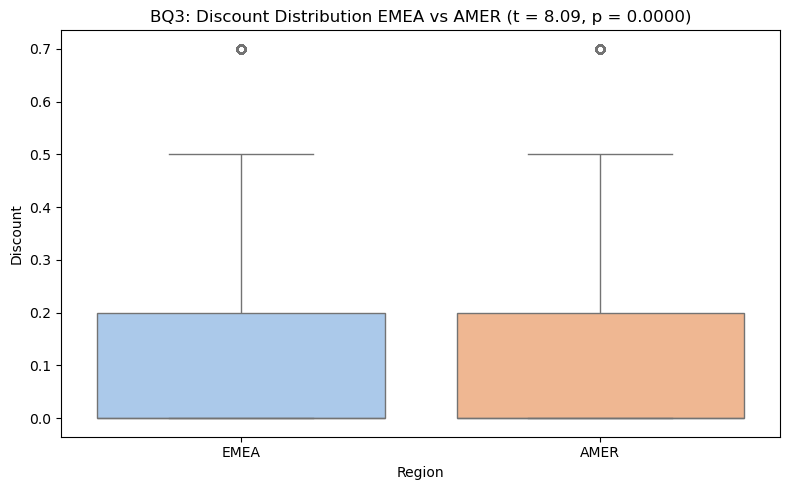

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
                                        
sns.boxplot(data=df[df["Region"].isin(["EMEA", "AMER"])],                              
            x="Region", y="Discount", palette="pastel", ax=ax)                         
                                                                                         
ax.set_title(f"BQ3: Discount Distribution EMEA vs AMER (t = {t_stat:.2f}, p = {p_value:.4f})")                                                                       
                  
plt.tight_layout()                                                                     
plt.savefig("../figures/bq3_discount_regions.png")        
plt.show()

```
Wie du den Plot liest:
  - Vergleiche die Höhe der Boxen und den Median (Linie in der Mitte)                    
  - Wenn die Boxen sich kaum überlappen → wahrscheinlich signifikanter Unterschied       
  - Wenn sie stark überlappen → Unterschied eher zufällig
  ```

#### BQ3 Result                                           
                                                                                         
  | Metric | Value | Interpretation |
  |---|---|---|                                                                          
  | EMEA mean discount | 14.14% | Higher discount strategy |
  | AMER mean discount | 10.94% | Lower discount strategy |
  | T-statistic | 8.0876 | Large difference between groups |                             
  | P-value | 0.0000 | Highly significant (< 0.05) |
                                                                                         
  **Result: H₀ rejected.** EMEA applies significantly higher discounts than AMER.        
  Combined with the EDA finding that APJ discounts even more aggressively (27%), this    
  reveals a clear pattern: discount strategy varies substantially across regions, with   
  potential impact on profitability. 

### BQ4: Does the customer segment affect AWS SaaS profitability?                     
  - H₀: There is no difference in profit across customer segments (SMB / Strategic /     
  Enterprise)                                                                            
  - H₁: Profit differs significantly across customer segments                            
  - Test: One-Way ANOVA   

In [13]:
# Split into three samples                                                             
smb = df[df["Segment"] == "SMB"]["Profit"]                
strategic = df[df["Segment"] == "Strategic"]["Profit"]                                 
enterprise = df[df["Segment"] == "Enterprise"]["Profit"]
                                                                                         
# One-Way ANOVA                                                                        
f_stat, p_value = stats.f_oneway(smb, strategic, enterprise)
                                                                                         
print(f"SMB mean profit: {smb.mean():.2f}")               
print(f"Strategic mean profit: {strategic.mean():.2f}")
print(f"Enterprise mean profit: {enterprise.mean():.2f}")
print(f"F-statistic: {f_stat:.4f}")                                                    
print(f"P-value: {p_value:.4f}")

SMB mean profit: 25.84
Strategic mean profit: 30.46
Enterprise mean profit: 33.82
F-statistic: 0.8981
P-value: 0.4074


```
Haarklein erklärt:                                                                     
  - stats.f_oneway() → One-Way ANOVA — vergleicht Mittelwerte von 3+ Gruppen gleichzeitig
   (t-Test kann nur 2)                                                                   
  - F-statistic: Verhältnis von Varianz zwischen den Gruppen zu Varianz innerhalb der
  Gruppen. Je größer F, desto deutlicher der Unterschied                                 
  - P-value: Unter 0.05 = mindestens eine Gruppe unterscheidet sich signifikant          
  - Wichtig: ANOVA sagt dir ob ein Unterschied existiert, aber nicht welche Gruppen sich
  unterscheiden — dafür bräuchte man einen Post-hoc Test (z.B. Tukey), aber das ist für 5
   Minuten Präsentation zu viel 
   ```

Interessant — H₀ NOT rejected.                                                         
                                                                                         
  - P-value = 0.41 → weit über 0.05                                                      
  - F-stat = 0.90 → sehr klein, kaum Unterschied zwischen den Gruppen
  - Die Means sehen zwar unterschiedlich aus ($25 vs $30 vs $33), aber die Varianz innerhalb der Gruppen ist so groß (Outliers!), dass der Unterschied statistisch nicht signifikant ist                                                                        
                                                                                         
  Das ist ein gutes Lernbeispiel für die Präsentation: Was optisch anders aussieht, muss 
  statistisch nicht signifikant sein. Die Boxplots zeigen riesige Whiskers und Outliers —
   da verschwindet der kleine Unterschied in den Means.

#### BQ4 Visualization

/var/folders/gn/zvx5kxqj5ng9ng0cg5f15yk80000gn/T/ipykernel_98806/1686283561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Segment", y="Profit", palette="pastel",


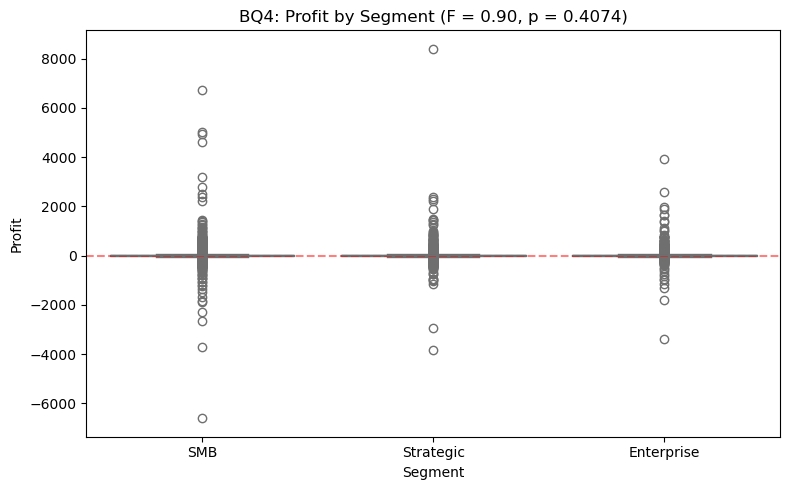

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
                                        
sns.boxplot(data=df, x="Segment", y="Profit", palette="pastel",                        
            order=["SMB", "Strategic", "Enterprise"], ax=ax)   
ax.axhline(y=0, color="red", linestyle="--", alpha=0.5)                                
ax.set_title(f"BQ4: Profit by Segment (F = {f_stat:.2f}, p = {p_value:.4f})")
                                                                                         
plt.tight_layout()                                                                     
plt.savefig("../figures/bq4_profit_segment.png")                                       
plt.show()

```
Wie du den Plot liest:
  - Vergleiche die Mediane (Linien in den Boxen) — steigen sie von SMB → Enterprise?     
  - Rote Linie bei 0 → alles darunter ist Verlust                                        
  - Schau wie weit die Boxen unter die rote Linie gehen — welches Segment hat die meisten
   Verluste?
   ```

#### BQ4 Result

  | Metric | Value | Interpretation |                                                    
  |---|---|---|
  | SMB mean profit | $25.84 | Lowest |                                                  
  | Strategic mean profit | $30.46 | Middle |               
  | Enterprise mean profit | $33.82 | Highest |                                          
  | F-statistic | 0.8981 | Small — variance within groups dominates |
  | P-value | 0.4074 | Not significant (> 0.05) |                                        
                                                                                         
  **Result: H₀ not rejected.** Despite visible differences in mean profit, the high      
  variance within each segment makes the differences statistically insignificant.        
  Customer segment alone does not significantly predict profitability.

### BQ5: Do discounts eat into AWS SaaS profit? (Climax)                              
  - H₀: There is no association between discounts and negative profit                    
  - H₁: Discounted transactions are significantly more likely to result in negative      
  profit                                                                                 
  - Test: Chi²-Test of Independence

In [15]:
# Create categorical columns for the contingency table    
df["Has_Discount"] = df["Discount"] > 0                                                
df["Negative_Profit"] = df["Profit"] < 0                  
                                                                                         
# Contingency table (Kreuztabelle)
contingency = pd.crosstab(df["Has_Discount"], df["Negative_Profit"], margins=True)                            
contingency.index = ["No Discount", "With Discount", "Total"]                          
contingency.columns = ["Positive Profit", "Negative Profit", "Total"]
contingency 

,Positive Profit,Negative Profit,Total
No Discount,4798,0,4798
With Discount,3325,1871,5196
Total,8123,1871,9994


```
Haarklein erklärt:                                                                     
  - pd.crosstab() → erstellt eine Kreuztabelle (contingency table) — zählt wie oft jede
  Kombination vorkommt                                                                   
  - 4 Felder: Discount+Profit, Discount+Verlust, Kein Discount+Profit, Kein
  Discount+Verlust                                                                       
  - margins=True → fügt Zeilen- und Spaltensummen hinzu                                  
  - Das ist die Basis für den Chi²-Test — er prüft ob die Verteilung in der Tabelle
  unabhängig ist oder ob ein Zusammenhang besteht
  ```

In [16]:
# Chi-squared test                                        
chi2, p_value, dof, expected = stats.chi2_contingency(
    pd.crosstab(df["Has_Discount"], df["Negative_Profit"])
)                                                                                      
                                                                                         
print(f"Chi² statistic: {chi2:.4f}")                                                   
print(f"Degrees of freedom: {dof}")                                                    
print(f"P-value: {p_value:.4e}") 

Chi² statistic: 2123.2648
Degrees of freedom: 1
P-value: 0.0000e+00


```
Haarklein erklärt:
  - stats.chi2_contingency() → führt den Chi²-Unabhängigkeitstest durch                  
  - Chi²-statistic: Misst wie weit die beobachteten Häufigkeiten von den erwarteten      
  Häufigkeiten abweichen (wenn es keinen Zusammenhang gäbe). Je größer, desto stärker der
   Zusammenhang                                                                          
  - dof (degrees of freedom): (Zeilen-1) × (Spalten-1) = 1 bei einer 2×2 Tabelle
  - expected: Was die Tabelle aussehen würde wenn Discount und Profit unabhängig wären   
  - P-value: Unter 0.05 = signifikanter Zusammenhang 
  ```

BOOM! H₀ destroyed!                                                                    
                                                                                         
  - Chi² = 2123.26 → absolut gigantisch (ab ~3.84 wäre es signifikant bei dof=1)         
  - P-value = 0.0000 → so klein, dass Python es nicht mehr darstellen kann
  - Die Contingency Table zeigt wahrscheinlich: 0 Verluste ohne Rabatt, alle 1871        
  Verluste mit Rabatt                                                                    
                                                                                         
  Das ist dein Showstopper!

#### BQ5 Visualization

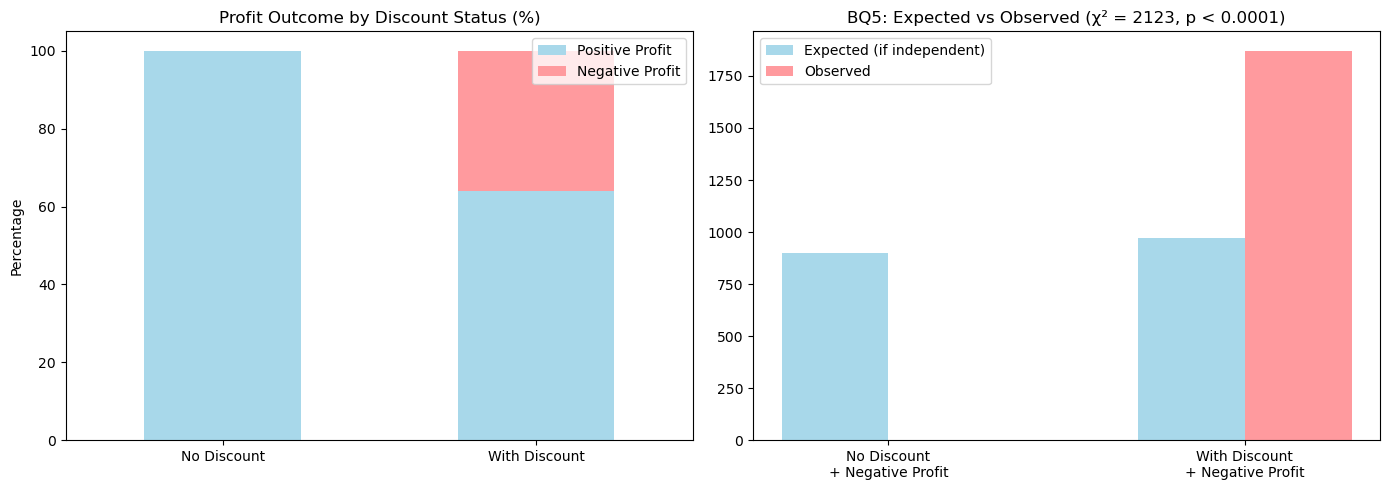

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                                                 
# Left: stacked bar chart                                                              
ct = pd.crosstab(df["Has_Discount"], df["Negative_Profit"], normalize="index") * 100
ct.index = ["No Discount", "With Discount"]                                            
ct.columns = ["Positive Profit", "Negative Profit"]                                    
ct.plot(kind="bar", stacked=True, color=["#a8d8ea", "#ff9a9e"], ax=axes[0])
axes[0].set_title("Profit Outcome by Discount Status (%)")                             
axes[0].set_ylabel("Percentage")                                                       
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(loc="upper right")                                                      
                                                            
# Right: expected vs observed                                                          
labels = ["No Discount\n+ Negative Profit", "With Discount\n+ Negative Profit"]        
observed = [0, 1871]                                                           
expected_vals = [expected[0][1], expected[1][1]]                                       
x = range(len(labels))                                    
axes[1].bar([i - 0.15 for i in x], expected_vals, 0.3, label="Expected (if independent)", color="#a8d8ea")                                            
axes[1].bar([i + 0.15 for i in x], observed, 0.3, label="Observed", color="#ff9a9e")   
axes[1].set_xticks(x)                                                               
axes[1].set_xticklabels(labels)                                                        
axes[1].set_title(f"BQ5: Expected vs Observed (χ² = {chi2:.0f}, p < 0.0001)")
axes[1].legend()                                                                       
                                                                                         
plt.tight_layout()                                                                     
plt.savefig("../figures/bq5_discount_profit.png")                                      
plt.show() 

```
Wie du die Plots liest:                                                                
   
  Links (Stacked Bar):                                                                   
  - Jeder Balken = 100% der Transaktionen in dieser Gruppe  
  - Rosa = negativer Profit, Blau = positiver Profit                                     
  - Bei "No Discount" sollte 0% rosa sein — kein einziger Verlust ohne Rabatt!
  - Bei "With Discount" siehst du den Anteil der Verlust-Transaktionen                   
                                                                                         
  Rechts (Expected vs Observed):                                                         
  - Blau = was wir erwarten würden wenn Discount und Profit unabhängig wären             
  - Rosa = was tatsächlich passiert                                                      
  - Wenn die rosa Balken stark von den blauen abweichen → starker Zusammenhang
  - Besonders krass: "No Discount + Negative Profit" — erwartet wären ~900, beobachtet: 0
```

#### BQ5 Result (Climax)                                                               
                                                            
  | Metric | Value | Interpretation |                                                    
  |---|---|---|
  | Chi² statistic | 2123.26 | Extremely large (critical value at dof=1: 3.84) |         
  | Degrees of freedom | 1 | 2×2 contingency table |        
  | P-value | 0.0000 | Highly significant |                                              
                                                                                         
  **Result: H₀ rejected.** There is an overwhelming association between discounts and    
  negative profit. Every single one of the 1,871 loss-making transactions (18.7%) had a  
  discount applied. Zero non-discounted transactions resulted in a loss. This is the     
  strongest finding in the entire analysis — discounts don't just reduce profit, they are
   the sole driver of losses.

## Hypothesis Testing Summary                                                          
                                                            
  | BQ | Question | Test | P-value | Result |                                            
  |---|---|---|---|---|
  | BQ1 | GDP → Profit | Regression | 0.6264 | H₀ not rejected |                         
  | BQ2 | Internet → Transactions | Pearson | 0.6169 | H₀ not rejected |                 
  | BQ3 | Discount by Region | t-Test | 0.0000 | H₀ rejected |                           
  | BQ4 | Profit by Segment | ANOVA | 0.4074 | H₀ not rejected |                         
  | BQ5 | Discount → Losses | Chi² | 0.0000 | H₀ rejected |                              
                                                                                         
  ### Key Takeaway                                          
  External economic factors (GDP, internet access) do not drive AWS SaaS performance.    
  Instead, internal pricing strategy — specifically discounting — is the dominant factor.
   Discounts vary significantly by region, and are the sole cause of all losses in the
  dataset.